In [1]:
pip install numpy pandas matplotlib


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



# Parameters

In [ ]:
# Simulation Parameters 
T = 1.0 # This is the total time - 10ms 
dt = 1e-4 # This is the time step
n_steps = int(T/dt) # Number of bins will be fitted inside total time "T", if we consider "dt" as each step
time = np.arange(0,T,dt) # Arrays of moments in time 

# LIF Neuron Parameter
V_rest = -0.065    # mV - resting voltage, when neurons are not reciving any signals. -ve beacuse there are lot of negative inside the cell (K) and positives outside the cell (Na)
V_th = -0.050      # spike threshold (mV), The threshold of around -50 mV is the specific voltage at which a large number of these voltage-gated sodium channels suddenly open
V_reset = -0.065   # reset voltage (mV)
R_m = 100e6       # MΩ A higher resistance means a larger voltage change for the same input current, making the neuron more excitable or "sensitive". A lower resistance means a smaller voltage change, making the neuron less sensitive (more "leaky")
C_m = 0.1e-9         # nF (100 pF) Total Capacitance = Specific Capacitance * Area -> Area = 4*pie*r^2 = 1*10^-5 = 1 * 1*10^-5 = 0.1nF
tau_m = R_m * C_m # ms
I_input = 1e-9     # nA constant current input, By providing a constant, suprathreshold input current, the simulation is set up to demonstrate tonic spiking (regular, repetitive firing) rather than just a single spike or no spikes at all. This allows you to study how the membrane potential changes over time
refractory_period = 5e-3 # ms

# Equation with Euler's Method

In [40]:
V = np.zeros(n_steps)
V[0] = V_rest
spikes = []
ref_countdown = 0



for i in range(1, n_steps):
    if ref_countdown > 0:
        V[i] = V_reset
        ref_countdown -= dt
        continue

    dV = (-(V[i-1] - V_rest) + R_m * I_input) / tau_m
    V[i] = V[i-1] + dV * dt

    if V[i] >= V_th:
        spikes.append(time[i])
        V[i] = V_reset
        ref_countdown = refractory_period


if len(spikes) == 0:
    print("No spikes detected — try increasing I_input or R_m.")
else:
    print(f"Total spikes: {len(spikes)} at times: {spikes[:10]} ms ...")


Total spikes: 147 at times: [0.0017000000000000001, 0.0085, 0.015300000000000001, 0.0221, 0.028900000000000002, 0.0357, 0.0425, 0.049300000000000004, 0.056100000000000004, 0.0629] ms ...


# Plot

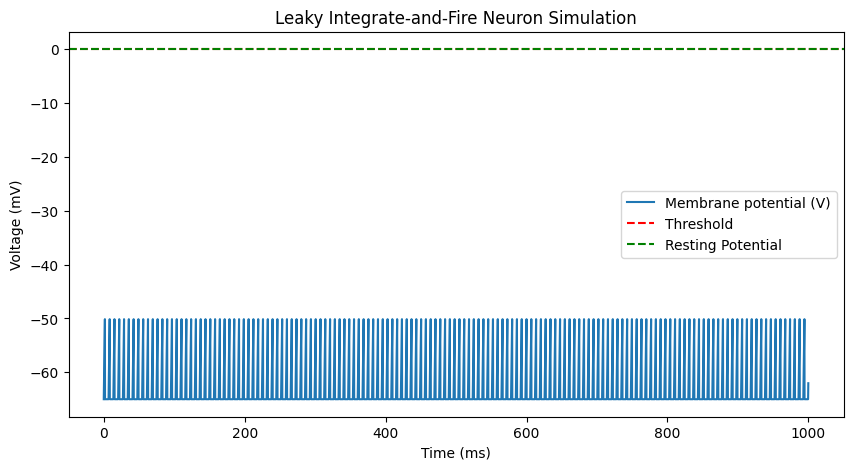

Max voltage (mV): -50.14577710948756


In [41]:
plt.figure(figsize=(10,5))
plt.plot(time * 1000, V*1000, label='Membrane potential (V)')
plt.axhline(V_th, color='r', linestyle='--', label='Threshold')
plt.axhline(V_rest, color='g', linestyle='--', label='Resting Potential')
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')
plt.title('Leaky Integrate-and-Fire Neuron Simulation')
plt.legend()
plt.show()
print("Max voltage (mV):", np.max(V)*1000)



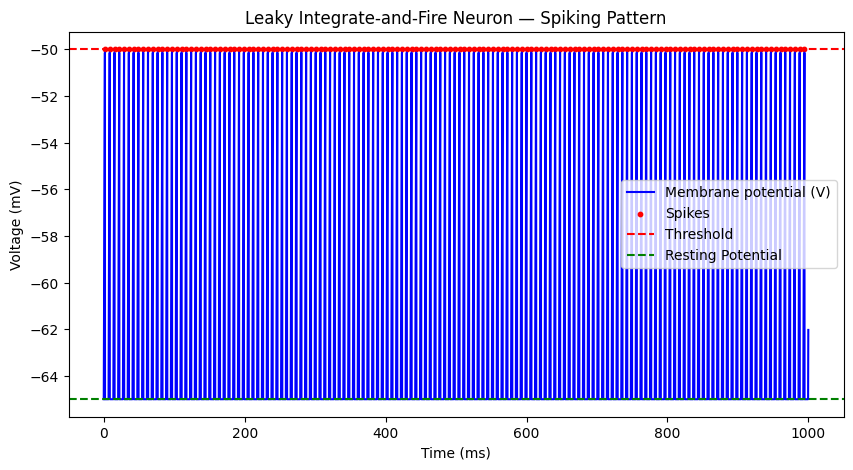

In [42]:
plt.figure(figsize=(10,5))
plt.plot(time * 1000, V * 1000, color='blue', label='Membrane potential (V)')
plt.scatter(np.array(spikes) * 1000, np.ones(len(spikes)) * V_th * 1000, 
            color='red', s=10, label='Spikes')
plt.axhline(V_th * 1000, color='r', linestyle='--', label='Threshold')
plt.axhline(V_rest * 1000, color='g', linestyle='--', label='Resting Potential')
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')
plt.title('Leaky Integrate-and-Fire Neuron — Spiking Pattern')
plt.legend()
plt.show()


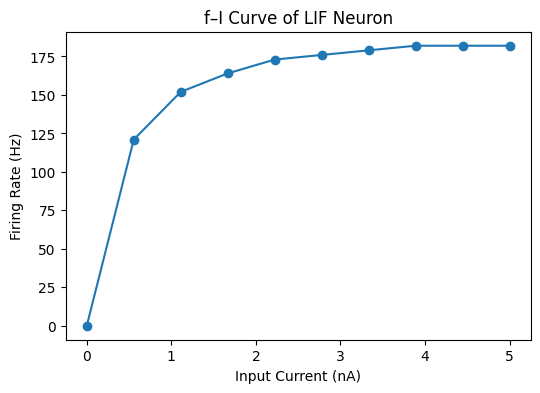

In [35]:
plt.figure(figsize=(6,4))
plt.plot(I_values*1e9, firing_rates, 'o-')
plt.xlabel('Input Current (nA)')
plt.ylabel('Firing Rate (Hz)')
plt.title('f–I Curve of LIF Neuron')
plt.show()


# Noise

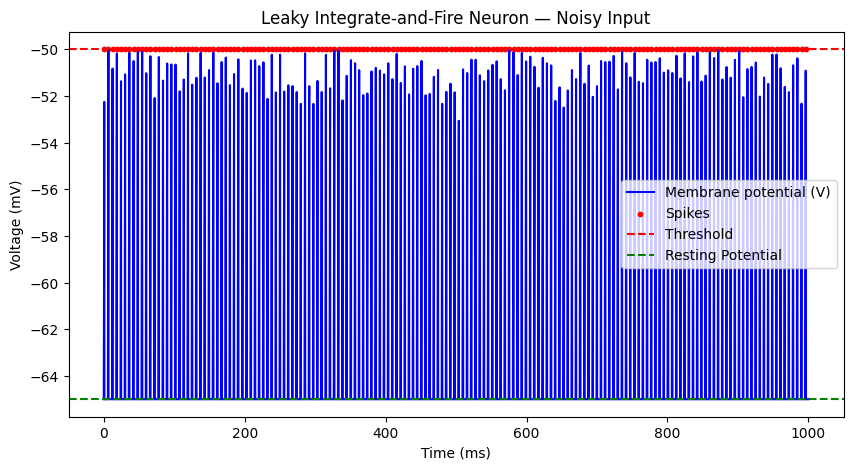

Total spikes: 169   |   Firing rate: 169.0 Hz


In [43]:
import numpy as np
import matplotlib.pyplot as plt

# --- Simulation Parameters ---
T = 1.0            # total simulation time (s)
dt = 1e-4          # timestep (s)
n_steps = int(T / dt)
time = np.arange(0, T, dt)

# --- LIF Neuron Parameters ---
V_rest = -0.065     # resting potential (V)
V_th = -0.050       # threshold potential (V)
V_reset = -0.065    # reset potential (V)
R_m = 100e6         # membrane resistance (ohms)
C_m = 0.1e-9        # membrane capacitance (farads)
tau_m = R_m * C_m   # membrane time constant (s)
I_mean = 2e-9       # mean input current (A)
noise_std = 0.5e-9  # standard deviation of noise (A)
refractory_period = 5e-3  # refractory period (s)

# --- Initialize variables ---
V = np.zeros(n_steps)
V[0] = V_rest
spikes = []
ref_countdown = 0

# --- Simulation Loop (Euler’s method with noise) ---
for i in range(1, n_steps):
    if ref_countdown > 0:
        V[i] = V_reset
        ref_countdown -= dt
        continue
    
    # Add Gaussian noise to current
    I_t = I_mean + np.random.normal(0, noise_std)
    
    # Euler integration of membrane voltage
    dV = (-(V[i-1] - V_rest) + R_m * I_t) / tau_m
    V[i] = V[i-1] + dV * dt
    
    # Spike condition
    if V[i] >= V_th:
        spikes.append(time[i])
        V[i] = V_reset
        ref_countdown = refractory_period

# --- Plot Results ---
plt.figure(figsize=(10, 5))
plt.plot(time * 1000, V * 1000, color='blue', label='Membrane potential (V)')
plt.scatter(np.array(spikes) * 1000, np.ones(len(spikes)) * V_th * 1000,
            color='red', s=10, label='Spikes')
plt.axhline(V_th * 1000, color='r', linestyle='--', label='Threshold')
plt.axhline(V_rest * 1000, color='g', linestyle='--', label='Resting Potential')
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')
plt.title('Leaky Integrate-and-Fire Neuron — Noisy Input')
plt.legend()
plt.show()

print(f"Total spikes: {len(spikes)}   |   Firing rate: {len(spikes)/T:.1f} Hz")
